In [41]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df=pd.read_csv('employee_satisfaction_sample.csv')

In [43]:
df=df.drop(columns='EmployeeID')

In [45]:
df.head()

,Department,Tenure,ManagerRating,WorkLifeBalance,GrowthOpportunities,SalarySatisfaction,OverallSatisfaction,WillStayNextYear
0,Tech,1.0,2.0,2.0,1.0,2.0,3,1
1,Operations,9.7,5.0,3.0,1.0,3.0,3,1
2,Sales,5.1,5.0,2.0,1.0,5.0,4,1
3,Tech,7.9,3.0,2.0,5.0,3.0,4,0
4,Tech,13.7,4.0,3.0,4.0,5.0,4,1


In [47]:
df_corr = df.corr(numeric_only=True)
df_corr

,Tenure,ManagerRating,WorkLifeBalance,GrowthOpportunities,SalarySatisfaction,OverallSatisfaction,WillStayNextYear
Tenure,1.000000,-0.054529,-0.053302,-0.062538,0.129529,-0.038013,0.007196
ManagerRating,-0.054529,1.000000,-0.002434,0.057506,0.031113,0.452662,0.216001
WorkLifeBalance,-0.053302,-0.002434,1.000000,-0.079486,-0.109105,0.182362,0.034484
GrowthOpportunities,-0.062538,0.057506,-0.079486,1.000000,-0.026357,0.376004,0.033162
SalarySatisfaction,0.129529,0.031113,-0.109105,-0.026357,1.000000,0.218155,0.108172
OverallSatisfaction,-0.038013,0.452662,0.182362,0.376004,0.218155,1.000000,0.256189
WillStayNextYear,0.007196,0.216001,0.034484,0.033162,0.108172,0.256189,1.000000


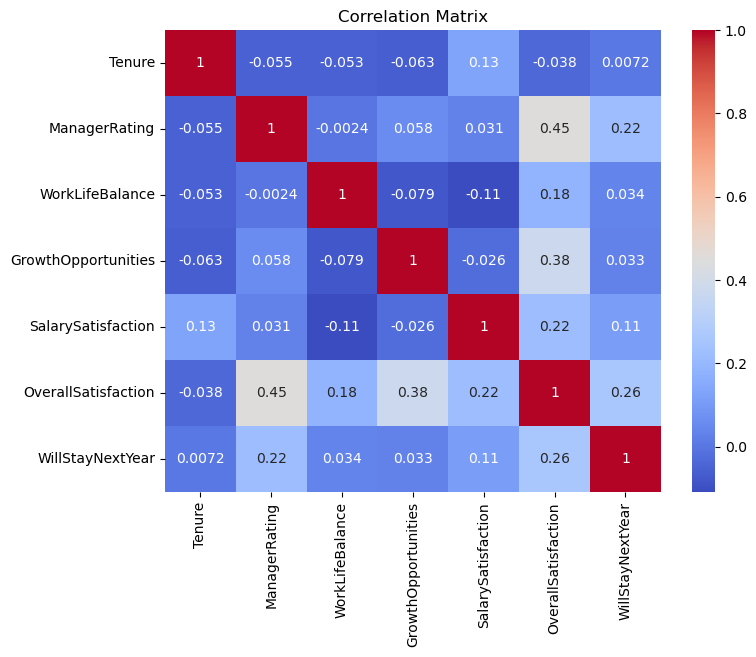

In [51]:
plt.figure(figsize=(8, 6))
sns.heatmap(df_corr, annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()


In [53]:
df_corr = df_corr['WillStayNextYear'].drop('WillStayNextYear')

In [55]:
df_corr

Tenure                 0.007196
ManagerRating          0.216001
WorkLifeBalance        0.034484
GrowthOpportunities    0.033162
SalarySatisfaction     0.108172
OverallSatisfaction    0.256189
Name: WillStayNextYear, dtype: float64

In [57]:
top_5_features = df_corr.abs().sort_values(ascending=False).head(5)
print(top_5_features)


OverallSatisfaction    0.256189
ManagerRating          0.216001
SalarySatisfaction     0.108172
WorkLifeBalance        0.034484
GrowthOpportunities    0.033162
Name: WillStayNextYear, dtype: float64


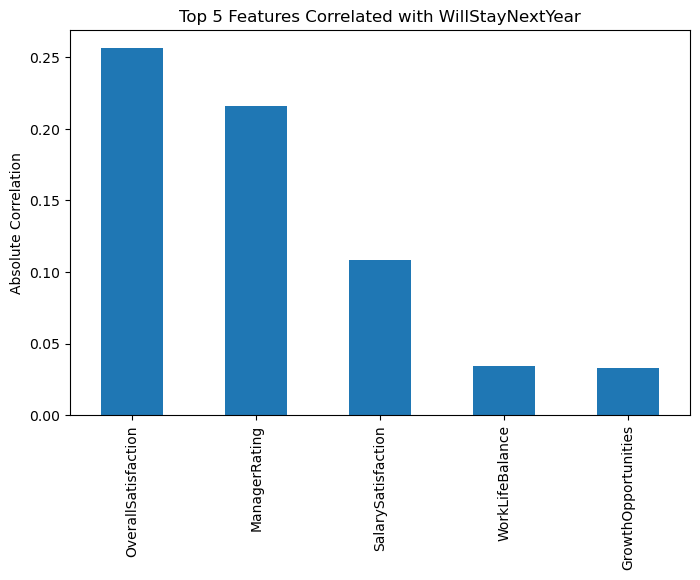

In [63]:
plt.figure(figsize=(8, 5))
top_5_features.plot(kind='bar')
plt.title('Top 5 Features Correlated with WillStayNextYear')
plt.ylabel('Absolute Correlation')
plt.show()

In [ ]:
## Top 5 cat_feature

In [77]:

categorical_cols = df.select_dtypes(include='object').columns
#categorical_cols
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)
corr = df_encoded.corr()
one_hot_cols = [col for col in df_encoded.columns if any(cat in col for cat in categorical_cols)]
target_corr_cat = corr['WillStayNextYear'][one_hot_cols]
top_5_cat = target_corr_cat.abs().sort_values(ascending=False).head(5)
print(top_5_cat)


Department_Operations    0.168427
Department_Sales         0.039544
Department_Tech          0.021641
Name: WillStayNextYear, dtype: float64


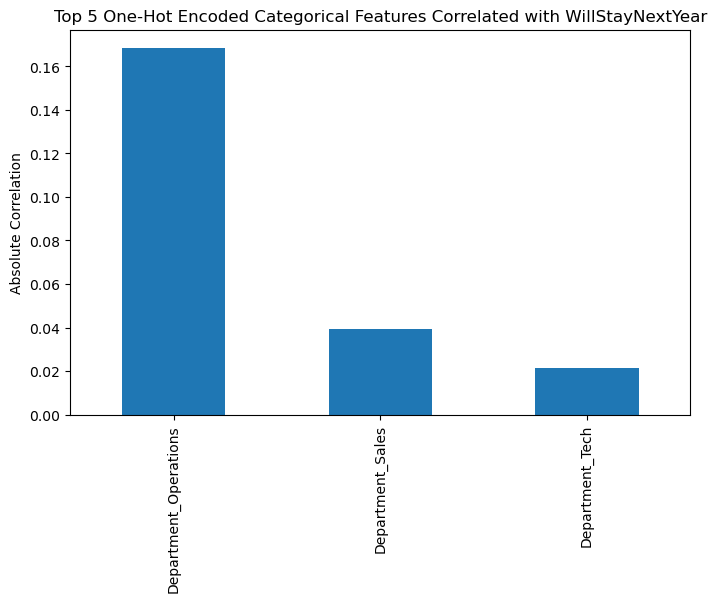

In [79]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
top_5_cat.plot(kind='bar')
plt.title('Top 5 One-Hot Encoded Categorical Features Correlated with WillStayNextYear')
plt.ylabel('Absolute Correlation')
plt.show()
